In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
detail_frequency=pd.read_csv('bikeshare/detail_frequency.csv')
weather_frequency=pd.read_csv('bikeshare/weather_frequency.csv')

## Comparative Analysis

### Weather and Usage Frequency

Our weather data covers an entire year, so we can categorize different weather conditions, seasons, temperatures, and precipitation to calculate bike rentals for different weather scenarios. 

We have each station's rental data for that site at different times of the year and in different weather conditions. First we calculate the average value of usage for each site in different weather conditions.

In [3]:
weather=weather_frequency.groupby('icon')[['pickup_counts','dropoff_counts']].mean().reset_index()
print(weather)

                icon  pickup_counts  dropoff_counts
0          clear-day      19.046134       18.823099
1             cloudy      19.254833       19.014380
2  partly-cloudy-day      20.157956       19.948999
3               rain      18.007153       17.789663
4               snow       8.356414        8.054096


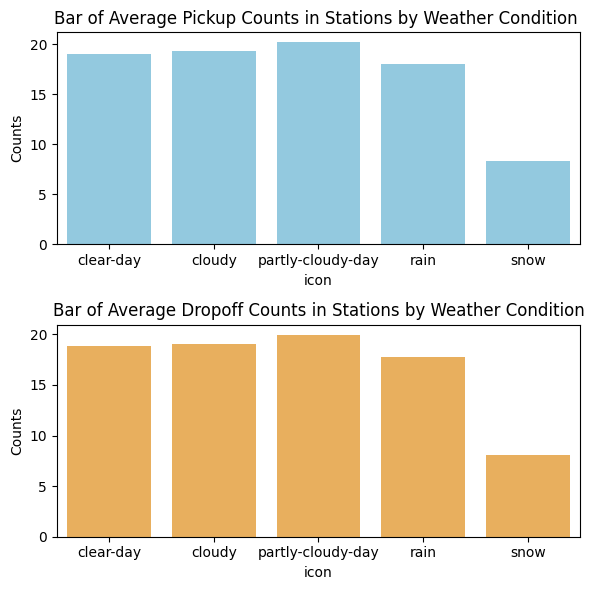

In [21]:

plt.figure(figsize=(6,6))

plt.subplot(2, 1, 1)
sns.barplot(data=weather, x='icon', y='pickup_counts',color='skyblue')
plt.title('Bar of Average Pickup Counts in Stations by Weather Condition ')
plt.ylabel('Counts')

plt.subplot(2, 1, 2)
sns.barplot(data=weather, x='icon', y='dropoff_counts', color='#FFB347')
plt.title('Bar of Average Dropoff Counts in Stations by Weather Condition')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()

According to the bar plot, we can see that the highest average number of rentals is in partly-cloudy-day and the lowest average number of rentals is in snowy day. This may due to the fact that the weather conditions on partly-cloudy-day are more suitable for traveling by bike and people are willing to travel by bike in this scenarios. Whereas snow days have poorer road conditions and are not suitable for bicycles.

In [5]:
weather_=weather_frequency[['icon','pickup_counts','dropoff_counts']].sort_values('icon')


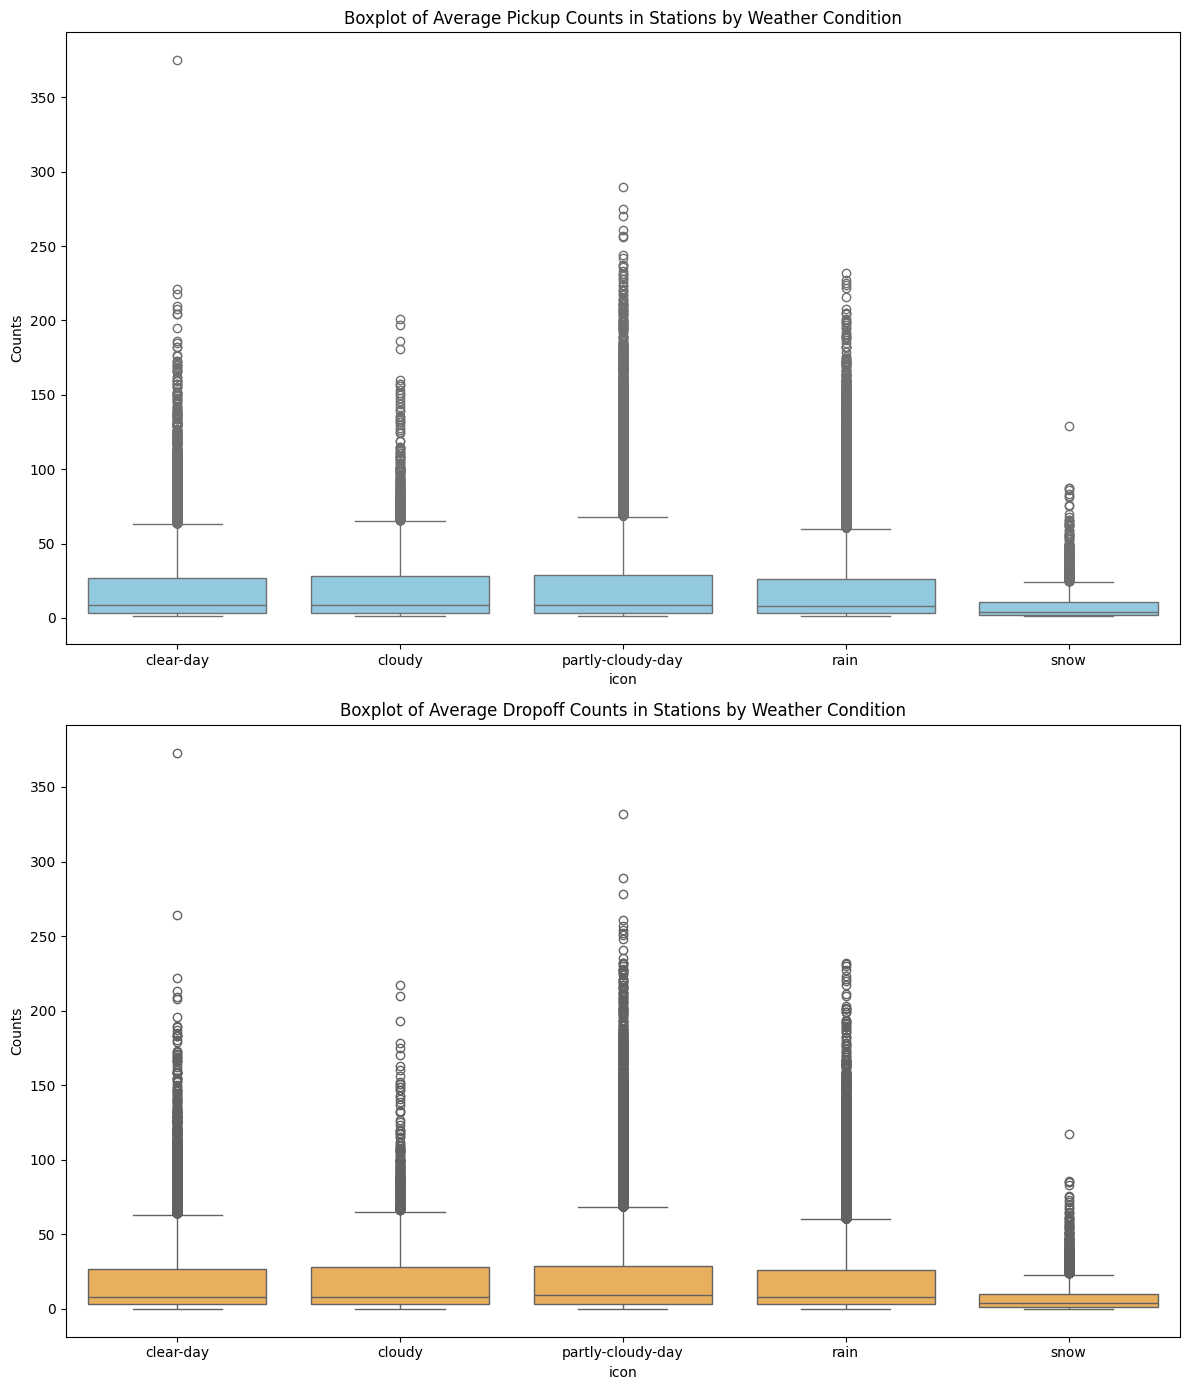

In [6]:
plt.figure(figsize=(12, 14))

plt.subplot(2, 1, 1)
sns.boxplot(data=weather_, x='icon', y='pickup_counts', color='skyblue')
plt.title('Boxplot of Average Pickup Counts in Stations by Weather Condition')
plt.ylabel('Counts')

plt.subplot(2, 1, 2)
sns.boxplot(data=weather_, x='icon', y='dropoff_counts', color='#FFB347')
plt.title('Boxplot of Average Dropoff Counts in Stations by Weather Condition')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()


Based on the results of barplots and boxplots, we can probably see that there is a significant difference in the status of bicycle rentals between snowy weather and other weather conditions. But for other weather conditions, we can't clearly find the difference between them. In order to get better results, we should do some statistical analysis such as anova.


In [7]:
model_pickup = ols('pickup_counts ~ C(icon)', data=weather_).fit()  # 'C(icon)' 表示将 icon 作为分类变量
anova_summary_pickup = anova_lm(model_pickup)

model_dropoff = ols('dropoff_counts ~ C(icon)', data=weather_).fit()
anova_summary_dropoff = anova_lm(model_dropoff)

print("ANOVA Summary for Pickup Counts:")
print(anova_summary_pickup)

print("\nANOVA Summary for Dropoff Counts:")
print(anova_summary_dropoff)

ANOVA Summary for Pickup Counts:
                df        sum_sq        mean_sq           F         PR(>F)
C(icon)        4.0  6.064559e+05  151613.983527  262.976647  6.785151e-226
Residual  225796.0  1.301782e+08     576.530217         NaN            NaN

ANOVA Summary for Dropoff Counts:
                df        sum_sq        mean_sq           F         PR(>F)
C(icon)        4.0  6.145131e+05  153628.269217  262.980935  6.727583e-226
Residual  225796.0  1.319056e+08     584.180252         NaN            NaN


In [8]:
tukey_pickup = pairwise_tukeyhsd(endog=weather_['pickup_counts'], groups=weather_['icon'], alpha=0.05)
print("Tukey HSD Results for Pickup Counts:")
print(tukey_pickup)

tukey_dropoff = pairwise_tukeyhsd(endog=weather_['dropoff_counts'], groups=weather_['icon'], alpha=0.05)
print("\nTukey HSD Results for Dropoff Counts:")
print(tukey_dropoff)

Tukey HSD Results for Pickup Counts:
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1            group2      meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------
        clear-day            cloudy   0.2087 0.9871  -0.9236    1.341  False
        clear-day partly-cloudy-day   1.1118    0.0   0.5579   1.6658   True
        clear-day              rain   -1.039    0.0  -1.6064  -0.4716   True
        clear-day              snow -10.6897    0.0 -11.9534  -9.4261   True
           cloudy partly-cloudy-day   0.9031 0.1133  -0.1203   1.9265  False
           cloudy              rain  -1.2477 0.0085  -2.2785  -0.2169   True
           cloudy              snow -10.8984    0.0 -12.4273  -9.3696   True
partly-cloudy-day              rain  -2.1508    0.0  -2.4464  -1.8552   True
partly-cloudy-day              snow -11.8015    0.0 -12.9687 -10.6344   True
             rain              snow  -9

Based on the results of the ANOVA, we found that at least one group had significantly different results from the others. That is, at least in one weather condition, bicycle rentals showed a significant difference from those in other weather scenarios.

In order to further explore in which weather conditions the number of rentals was significantly different, we used the TukeyHSD method to perform the POST-HOC analysis of the ANOVA.
For pickup counts, the groups that showed significant differences at the 0.05 level were: 
- clear-day and partly-cloudy-day
- clear-day and rain
- clear-day and snow
- cloudy and rain
- cloudy and snow
- partly-cloudy-day and rain
- partly-cloudy-day and snow
- rain and snow

For dropoff counts, results are the same.

Based on the above analysis, we can primarily conclude that partly-cloudy-day has the highest frequency of bike rentals. Snowy day has the least rental frequency. Bicycle rental frequency in most cases varies across weather scenario categories.

### Season and Frequency Usage.

We can analyze whether seasonal differences lead to differences in bicycle rentals by dividing the time of year into four seasons. Unlike weather scenarios, the seasonal categorization affects bikeshare by not only the temperature and precipitation conditions, but also the activity patterns of people at different times of the year.

In our analysis:
- March, April, May are regarded as spring.
- June, July, August are regarded as summer.
- September, October, November are regarded as autumn.
- December, January, February are regarded as winter.

In [9]:
def assign_season(month):

    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    elif month in [12, 1, 2]:
        return 'Winter'
    
weather_frequency['date'] = pd.to_datetime(weather_frequency['date'], errors='coerce')
weather_frequency['month']=weather_frequency['date'].dt.month
weather_frequency['season_tag'] = weather_frequency['month'].apply(assign_season)

In [10]:
season_=weather_frequency[['season_tag','pickup_counts','dropoff_counts']]
season=season_.groupby('season_tag')[['pickup_counts','dropoff_counts']].mean().reset_index()

In [11]:
season=season.loc[[1,2,0,3],:]
print(season)

  season_tag  pickup_counts  dropoff_counts
1     Spring      20.498776       20.276743
2     Summer      21.146151       20.968600
0       Fall      20.309761       20.090482
3     Winter      13.781254       13.535713


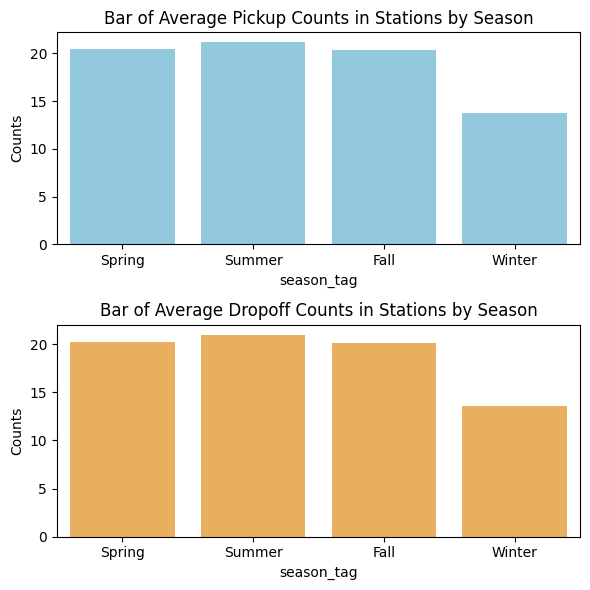

In [22]:

plt.figure(figsize=(6,6))

plt.subplot(2, 1, 1)
sns.barplot(data=season, x='season_tag', y='pickup_counts', color='skyblue')
plt.title('Bar of Average Pickup Counts in Stations by Season')
plt.ylabel('Counts')

plt.subplot(2, 1, 2)
sns.barplot(data=season, x='season_tag', y='dropoff_counts', color='#FFB347')
plt.title('Bar of Average Dropoff Counts in Stations by Season')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()

According to the bar plot, we can see that the highest average number of rentals is in summer and the lowest average number of rentals is in winter. This may due to the fact that the weather conditions on summer are more suitable for traveling by bike. Whereas winter has a lot of snowy days which lead to poorer road conditions and are not suitable for bicycles.

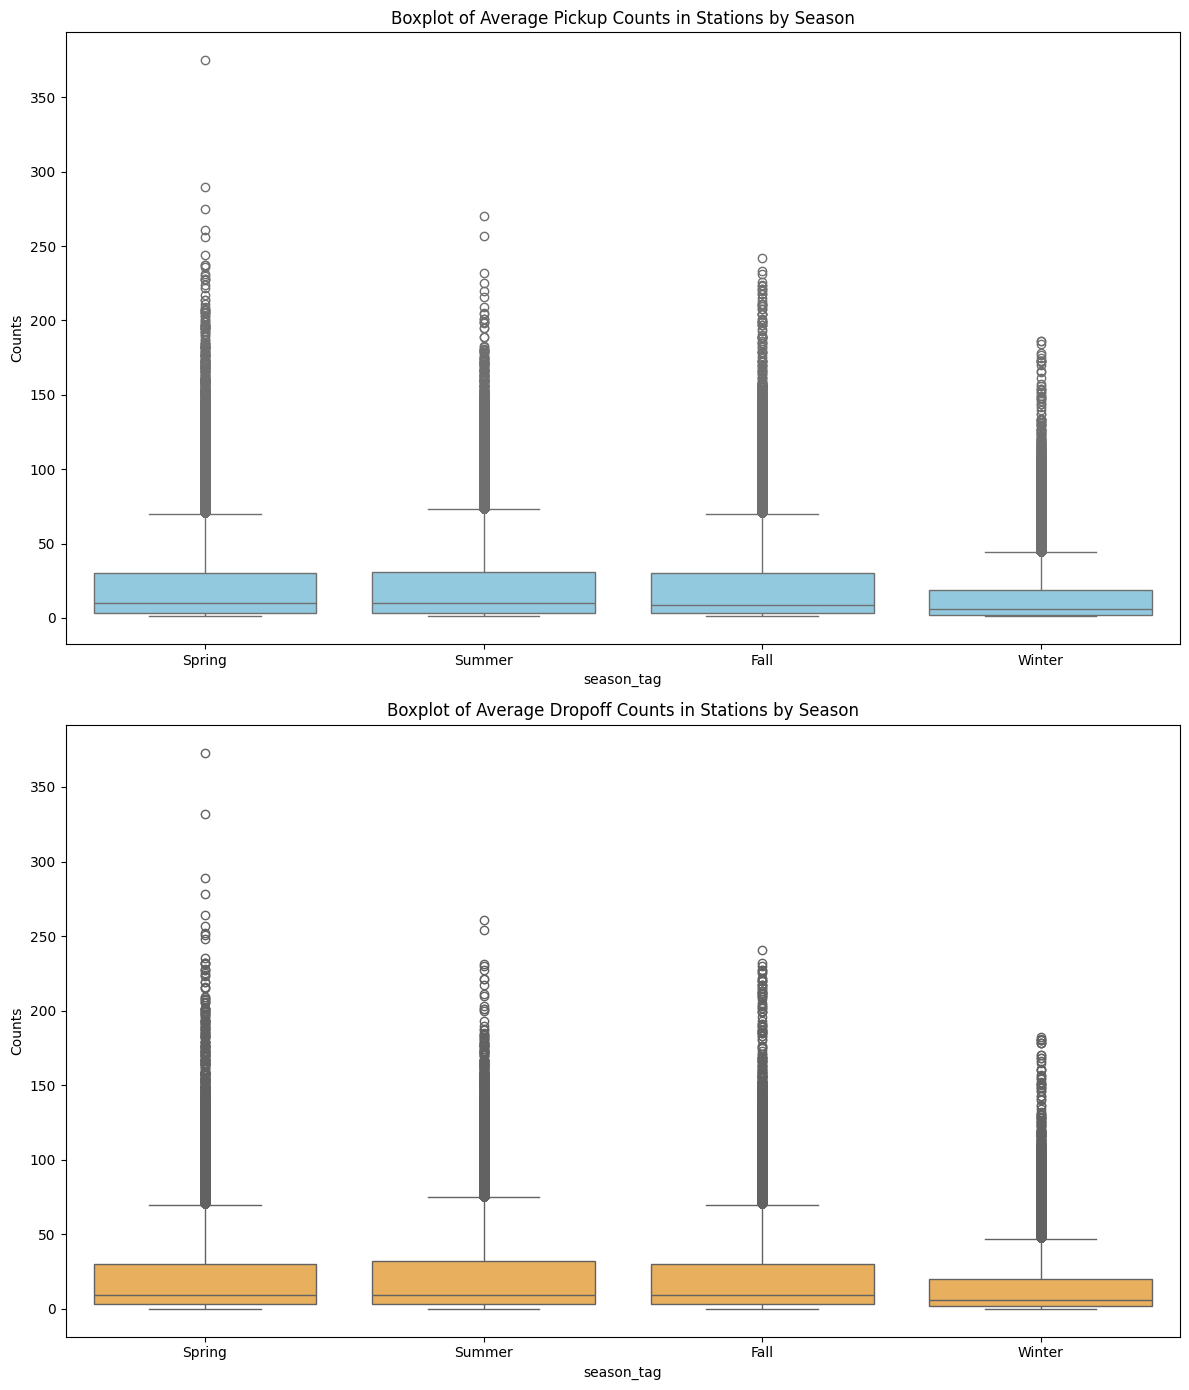

In [31]:
plt.figure(figsize=(12, 14))

plt.subplot(2, 1, 1)
sns.boxplot(data=season_, x='season_tag', y='pickup_counts', color='skyblue')
plt.title('Boxplot of Average Pickup Counts in Stations by Season')
plt.ylabel('Counts')

plt.subplot(2, 1, 2)
sns.boxplot(data=season_, x='season_tag', y='dropoff_counts', color='#FFB347')
plt.title('Boxplot of Average Dropoff Counts in Stations by Season')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()

Based on the results of barplots and boxplots, we can probably see that there is a significant difference in the status of bicycle rentals between winter and other weather conditions. But for other season, we can't clearly find the difference between them. In order to get better results, we should do some statistical analysis such as anova.

In [14]:
model_pickup = ols('pickup_counts ~ C(season_tag)', data=season_).fit()  # 'C(icon)' 表示将 icon 作为分类变量
anova_summary_pickup = anova_lm(model_pickup)

model_dropoff = ols('dropoff_counts ~ C(season_tag)', data=season_).fit()
anova_summary_dropoff = anova_lm(model_dropoff)

print("ANOVA Summary for Pickup Counts:")
print(anova_summary_pickup)

print("\nANOVA Summary for Dropoff Counts:")
print(anova_summary_dropoff)

ANOVA Summary for Pickup Counts:
                     df        sum_sq        mean_sq            F  PR(>F)
C(season_tag)       3.0  1.894934e+06  631644.564835  1106.553933     0.0
Residual       225797.0  1.288897e+08     570.821309          NaN     NaN

ANOVA Summary for Dropoff Counts:
                     df        sum_sq        mean_sq            F  PR(>F)
C(season_tag)       3.0  1.919025e+06  639675.055971  1105.938323     0.0
Residual       225797.0  1.306011e+08     578.400298          NaN     NaN


In [15]:
tukey_pickup = pairwise_tukeyhsd(endog=season_['pickup_counts'], groups=season_['season_tag'], alpha=0.05)
print("Tukey HSD Results for Pickup Counts:")
print(tukey_pickup)

tukey_dropoff = pairwise_tukeyhsd(endog=season_['dropoff_counts'], groups=season_['season_tag'], alpha=0.05)
print("\nTukey HSD Results for Dropoff Counts:")
print(tukey_dropoff)

Tukey HSD Results for Pickup Counts:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Fall Spring    0.189 0.5348 -0.1723  0.5503  False
  Fall Summer   0.8364    0.0  0.4755  1.1973   True
  Fall Winter  -6.5285    0.0 -6.9027 -6.1543   True
Spring Summer   0.6474    0.0  0.2899  1.0049   True
Spring Winter  -6.7175    0.0 -7.0884 -6.3466   True
Summer Winter  -7.3649    0.0 -7.7354 -6.9944   True
----------------------------------------------------

Tukey HSD Results for Dropoff Counts:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Fall Spring   0.1863 0.5528 -0.1774  0.5499  False
  Fall Summer   0.8781    0.0  0.5148  1.2414   True
  Fall Winter  -6.5548    0.0 -6.9314 -6.1781   True
Spring Summer   0.6919    0.0   0.332  1.0517   True
Spring Winter   -6.741 

Based on the results of the ANOVA, we found that at least one group had significantly different results from the others. That is, at least in one season, bicycle rentals showed a significant difference from those in other season.

In order to further explore in which season the number of rentals was significantly different, we used the TukeyHSD method to perform the POST-HOC analysis of the ANOVA.
For pickup counts, the groups that showed significant differences at the 0.05 level were: 
- Fall and Summer
- Fall and Winter
- Spring and Summer
- Spring and Winter
- Summer and Winter

For dropoff counts, results are the same.

Based on the above analysis, we can primarily conclude that summertime has the highest frequency of bike rentals. Winter has the least rental frequency. Weather conditions and crowd activity patterns are similar in the spring and fall, so there is no significant difference in bike rentals between these two seasons.

### Weekday/Weekend Analysis

We suspect that people's bike rentals may vary during on the weekday and on the weekend. Therefore, we divided the data into two groups and do the comparative analysis to see if there are some differences in the bike rental data in two time periods

In [26]:
weather_frequency['day_tag'] = weather_frequency['date'].dt.weekday.apply(lambda x: 'weekday' if x < 5 else 'weekend')
print(weather_frequency['day_tag'].value_counts())

day_tag
weekday    162359
weekend     63442
Name: count, dtype: int64


In [27]:
weekday=weather_frequency.groupby('day_tag')[['pickup_counts','dropoff_counts']].mean().reset_index()
print(weekday)

   day_tag  pickup_counts  dropoff_counts
0  weekday      19.041796       18.818618
1  weekend      19.235711       19.041502


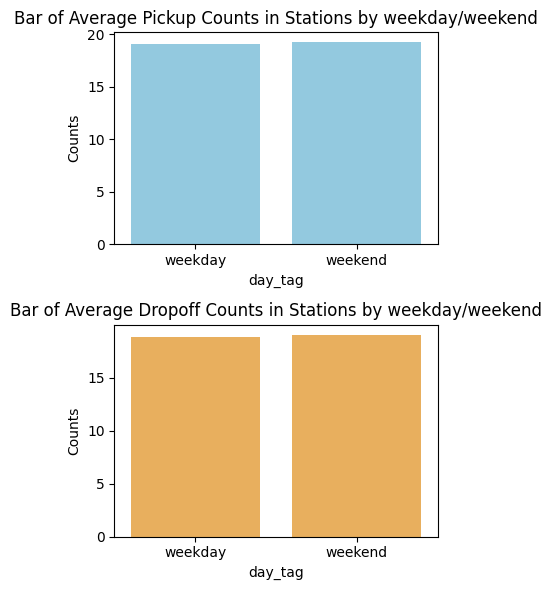

In [28]:

plt.figure(figsize=(4,6))

plt.subplot(2, 1, 1)
sns.barplot(data=weekday, x='day_tag', y='pickup_counts', color='skyblue')
plt.title('Bar of Average Pickup Counts in Stations by weekday/weekend')
plt.ylabel('Counts')

plt.subplot(2, 1, 2)
sns.barplot(data=weekday, x='day_tag', y='dropoff_counts', color='#FFB347')
plt.title('Bar of Average Dropoff Counts in Stations by weekday/weekend')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()

In [29]:
weekday_=weather_frequency[['pickup_counts','dropoff_counts','day_tag']]

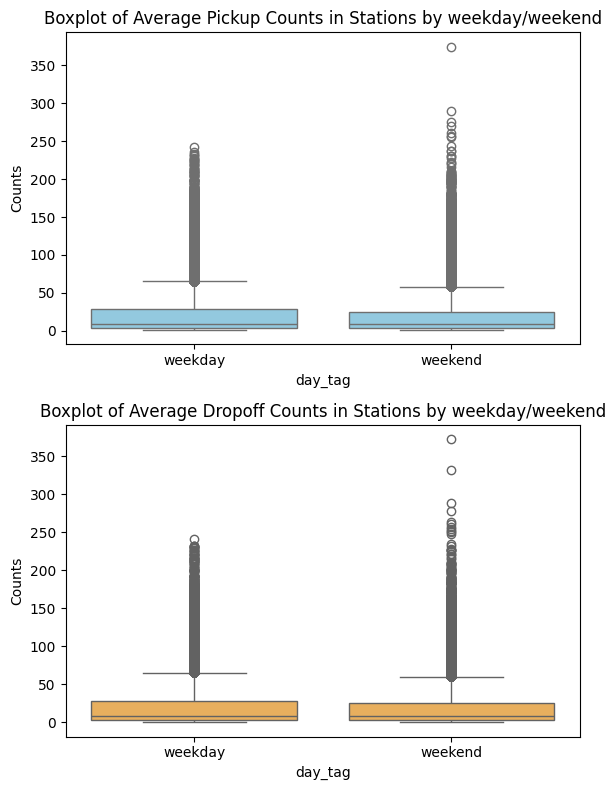

In [33]:
plt.figure(figsize=(6,8))

plt.subplot(2, 1, 1)
sns.boxplot(data=weekday_, x='day_tag', y='pickup_counts', color='skyblue')
plt.title('Boxplot of Average Pickup Counts in Stations by weekday/weekend')
plt.ylabel('Counts')

plt.subplot(2, 1, 2)
sns.boxplot(data=weekday_, x='day_tag', y='dropoff_counts', color='#FFB347')
plt.title('Boxplot of Average Dropoff Counts in Stations by weekday/weekend')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()

We can't see any difference just from the bar chart and boxplot. Therefore we need to perform statistical analysis such as ANOVA.

In [34]:
model_pickup = ols('pickup_counts ~ C(day_tag)', data=weekday_).fit()  # 'C(icon)' 表示将 icon 作为分类变量
anova_summary_pickup = anova_lm(model_pickup)

model_dropoff = ols('dropoff_counts ~ C(day_tag)', data=weekday_).fit()
anova_summary_dropoff = anova_lm(model_dropoff)

print("ANOVA Summary for Pickup Counts:")
print(anova_summary_pickup)

print("\nANOVA Summary for Dropoff Counts:")
print(anova_summary_dropoff)

ANOVA Summary for Pickup Counts:
                  df        sum_sq      mean_sq         F    PR(>F)
C(day_tag)       1.0  1.715341e+03  1715.341497  2.961566  0.085267
Residual    225799.0  1.307830e+08   579.200783       NaN       NaN

ANOVA Summary for Dropoff Counts:
                  df        sum_sq      mean_sq         F    PR(>F)
C(day_tag)       1.0  2.266141e+03  2266.141403  3.861311  0.049413
Residual    225799.0  1.325178e+08   586.883960       NaN       NaN


According to anova results, we can find that at the level of alpha=0.1, the data for both pickup and dropoff are significantly different at different times of the week.

In [35]:
tukey_pickup = pairwise_tukeyhsd(endog=weekday_['pickup_counts'], groups=weekday_['day_tag'], alpha=0.1)
print("Tukey HSD Results for Pickup Counts:")
print(tukey_pickup)

tukey_dropoff = pairwise_tukeyhsd(endog=weekday_['dropoff_counts'], groups=weekday_['day_tag'], alpha=0.1)
print("\nTukey HSD Results for Dropoff Counts:")
print(tukey_dropoff)

Tukey HSD Results for Pickup Counts:
Multiple Comparison of Means - Tukey HSD, FWER=0.10 
 group1  group2 meandiff p-adj  lower  upper  reject
----------------------------------------------------
weekday weekend   0.1939 0.0853 0.0086 0.3793   True
----------------------------------------------------

Tukey HSD Results for Dropoff Counts:
Multiple Comparison of Means - Tukey HSD, FWER=0.10 
 group1  group2 meandiff p-adj  lower  upper  reject
----------------------------------------------------
weekday weekend   0.2229 0.0494 0.0363 0.4095   True
----------------------------------------------------


Based on the results of tukeyHSD, we can see that the number of bike rentals will be slightly higher on weekends than during the week. This may be because for some people who don't ride bicycles for commuting during the weekday, they use bicycles in more scenarios on weekends, such as as part of excursions, sports, and so on. However this difference is only more pronounced at the 0.1 level. If we set the alpha to 0.05, then only the difference between groups for dropoff is significant. For the discrepancy between pickup and dropoff results, we speculate that it is because some people pick up bikes during the weekday and return them on the weekend.

## Multivariate Analysis

### Bike Type and Member Type

In our detail records, we find that the data records the type of bike being rented that corresponds to each record, as well as the VIP status of the user who rented this bike. So we made a pivot table and heatmap to observe if there is any correlation between them. 

We normalized all the results when performing the calculations. The values shown in the pivot table and heatmap are the current category as a percentage of the total.

In [16]:
member_bike = pd.crosstab(detail_frequency['member_casual'],detail_frequency['rideable_type'],margins=True)

total_sum = member_bike.loc['All', 'All']
member_bike_normalized = member_bike / total_sum * 100
print(member_bike_normalized)


rideable_type  classic_bike  docked_bike  electric_bike         All
member_casual                                                      
casual            24.988027     1.704221      10.553297   37.245545
member            46.575072     0.000000      16.179383   62.754455
All               71.563099     1.704221      26.732680  100.000000


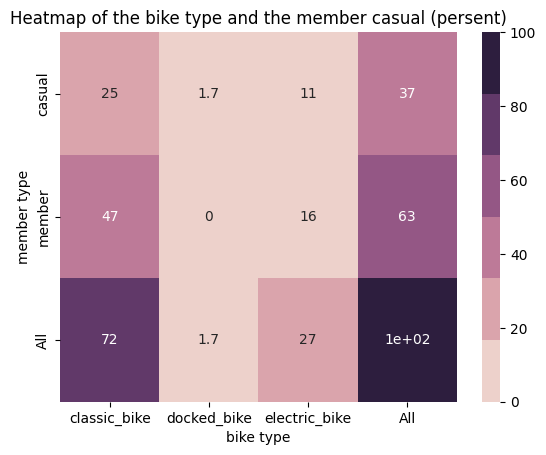

In [17]:
sns.heatmap(member_bike_normalized,annot=True,cmap=sns.cubehelix_palette())
plt.title("Heatmap of the bike type and the member casual (persent)")
plt.xlabel('bike type')
plt.ylabel('member type')
plt.show()

This is an interesting result. We can see that the most records were recorded for renting classic bikes, followed by electric bikes, and finally docked bikes. This may because that for this bikeshare company, the most placed bikes that were classic bikes.

We also find that there are more member users than casual users among those who rented classic bikes and e-bikes. But for docked bikes, only casual users pickup them.

### Rent Duration and Member Type

We want to observe the distribution of the bike rental duration for different types of users. 

In this step, we performed a simple filter on the length of rentals thereby removing the excessively large portion of the data. Since our two user groups have different totals, we normalized the histograms so that we could better see the difference in their distributions.

In [41]:
detail_frequency['started_at'] = pd.to_datetime(detail_frequency['started_at'])
detail_frequency['ended_at'] = pd.to_datetime(detail_frequency['ended_at'])


detail_frequency['rent_duration'] = detail_frequency['ended_at'] - detail_frequency['started_at']
detail_frequency['rent_duration'] = detail_frequency['rent_duration'].dt.total_seconds()

In [51]:

member_duration=detail_frequency.loc[detail_frequency['member_casual']=='member',['rent_duration','member_casual']]
casual_duration=detail_frequency.loc[detail_frequency['member_casual']=='casual',['rent_duration','member_casual']]

threshold_member = member_duration['rent_duration'].quantile(0.99)
threshold_casual = casual_duration['rent_duration'].quantile(0.99)

filtered_member_duration = member_duration[(member_duration['rent_duration'] <= threshold_member) & (member_duration['rent_duration'] >=0)]
filtered_casual_duration = casual_duration[(casual_duration['rent_duration'] <= threshold_casual) & (casual_duration['rent_duration'] >=0)]


In [52]:
filtered_member_duration.head()

,rent_duration,member_casual
1,943.0,member
2,787.0,member
3,786.0,member
5,194.0,member
6,1376.0,member


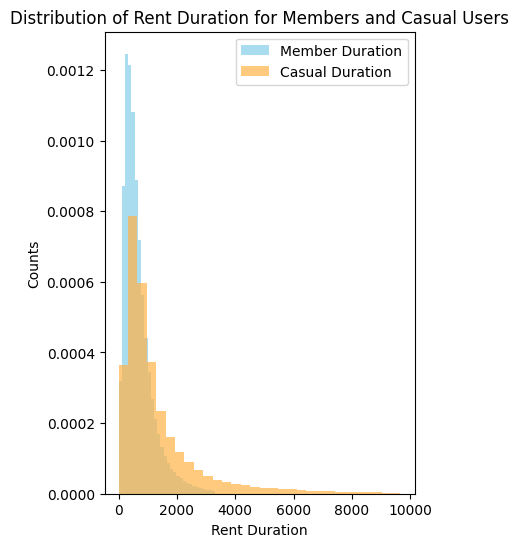

In [55]:

plt.figure(figsize=(4,6))

plt.hist(filtered_member_duration['rent_duration'], bins=30, color='skyblue', alpha=0.7, label='Member Duration',density=True)
plt.hist(filtered_casual_duration['rent_duration'], bins=30, color='#FFB347', alpha=0.7, label='Casual Duration',density=True)

plt.title('Distribution of Rent Duration for Members and Casual Users')
plt.xlabel('Rent Duration')
plt.ylabel('Counts')

plt.legend()

plt.show()

Based on the results we can find that member users rent mainly distribute in shorter duration intervals and casual users prefer to rent for longer durations. This may because that for this company's bike rental service, non-members get a better deal for longer rent duration, which may be due to the presence of a starting price. Once they become a member, their short-term rentals are cheaper.